# Raman Spectroscopy - Blood Glucose Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
# 2. Load Dataset

df = pd.read_csv("C:/Users/serin/Downloads/Raman Spectroscopy Glucose.csv")
print("\nDataset Loaded Successfully")


Dataset Loaded Successfully


In [4]:
wave_cols = [c for c in df.columns if c.startswith("wave_")]

print("Total Spectral Features:", len(wave_cols))

Total Spectral Features: 2048


In [5]:
print("\nDataset Shape:", df.shape)
print("Total Samples:", df.shape[0])
print("Total Columns:", df.shape[1])


Dataset Shape: (10000, 2051)
Total Samples: 10000
Total Columns: 2051


In [6]:
print("\nDataset Information")
df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 2051 entries, sample_id to high_glucose
dtypes: float64(2049), int64(2)
memory usage: 156.5 MB


In [7]:
print("\nFirst 5 Rows")
print(df.head())


First 5 Rows
   sample_id   wave_1   wave_2   wave_3   wave_4   wave_5   wave_6   wave_7  \
0          1  25235.3  25531.1  29990.1  31869.0  25587.1  23101.4  22457.9   
1          2  10504.8  12091.9  14121.3  16181.2  19159.9  21780.5  25347.3   
2          3  15262.1  16880.4  19955.2  21908.4  24543.8  26194.3  29119.4   
3          4  18932.6  19587.0  23391.3  25810.9  25222.8  25790.7  27284.6   
4          5  18623.1  19435.5  23259.9  24946.7  25881.8  25803.3  28795.7   

    wave_8   wave_9  ...  wave_2041  wave_2042  wave_2043  wave_2044  \
0  21917.6  22026.3  ...      312.9      329.2      330.6      264.6   
1  28786.1  31559.0  ...      251.3      262.2      293.5      149.6   
2  32927.1  34481.9  ...      335.3      286.8      336.9      231.4   
3  29410.2  30991.3  ...      308.9      276.1      307.5      233.3   
4  30052.3  28673.8  ...      651.0      620.7      541.1      656.6   

   wave_2045  wave_2046  wave_2047  wave_2048  glucose_mM  high_glucose  
0   

In [8]:
print("\nStatistical Summary")
print(df[['glucose_mM','high_glucose']].describe())



Statistical Summary
         glucose_mM  high_glucose
count  10000.000000  10000.000000
mean      76.653174      0.650000
std       41.706356      0.476993
min        5.000000      0.000000
25%       40.717500      0.000000
50%       76.420000      1.000000
75%      112.305000      1.000000
max      149.960000      1.000000


In [9]:

print("\nMissing Values Check")

missing_total = df.isnull().sum().sum()

print("Total Missing Values:", missing_total)



Missing Values Check
Total Missing Values: 0


In [10]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)



Duplicate Rows: 0


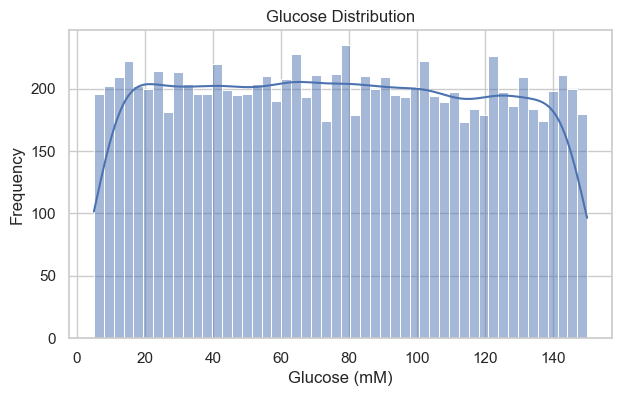

In [11]:

plt.figure(figsize=(7,4))

sns.histplot(df['glucose_mM'], bins=50, kde=True)

plt.title("Glucose Distribution")

plt.xlabel("Glucose (mM)")
plt.ylabel("Frequency")

plt.show()

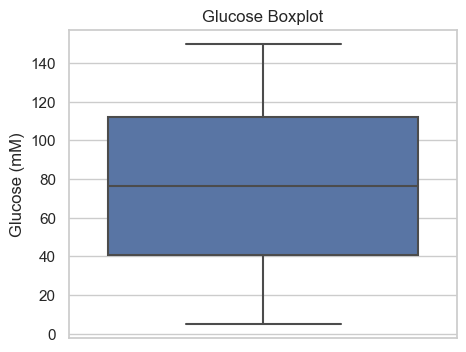

In [12]:
plt.figure(figsize=(5,4))

sns.boxplot(y=df['glucose_mM'])

plt.title("Glucose Boxplot")

plt.ylabel("Glucose (mM)")

plt.show()


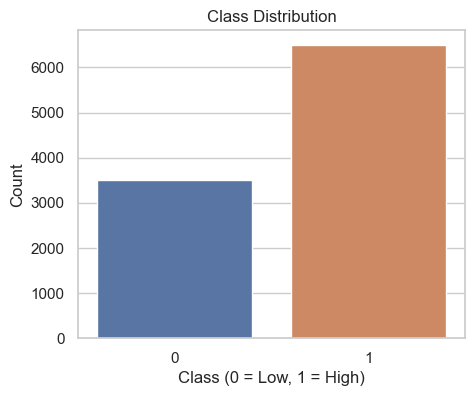

In [13]:
plt.figure(figsize=(5,4))

sns.countplot(x='high_glucose', data=df)

plt.title("Class Distribution")

plt.xlabel("Class (0 = Low, 1 = High)")
plt.ylabel("Count")

plt.show()

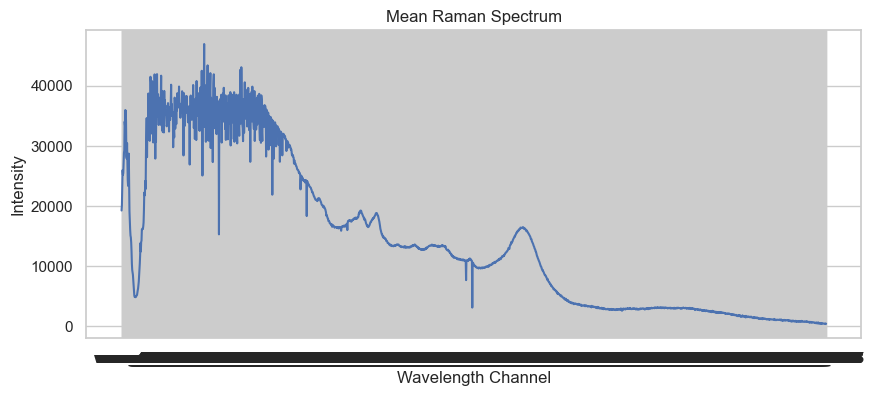

In [14]:
mean_spectrum = df[wave_cols].mean()

plt.figure(figsize=(10,4))

plt.plot(mean_spectrum)

plt.title("Mean Raman Spectrum")

plt.xlabel("Wavelength Channel")

plt.ylabel("Intensity")

plt.show()

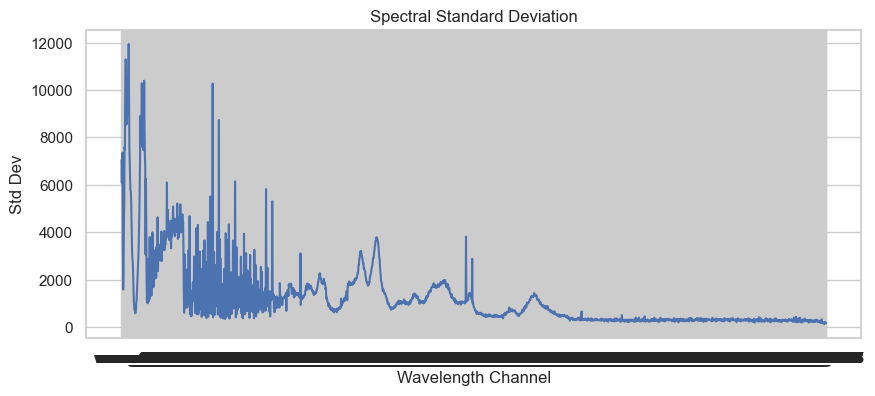

In [15]:

std_spectrum = df[wave_cols].std()

plt.figure(figsize=(10,4))

plt.plot(std_spectrum)

plt.title("Spectral Standard Deviation")

plt.xlabel("Wavelength Channel")

plt.ylabel("Std Dev")

plt.show()



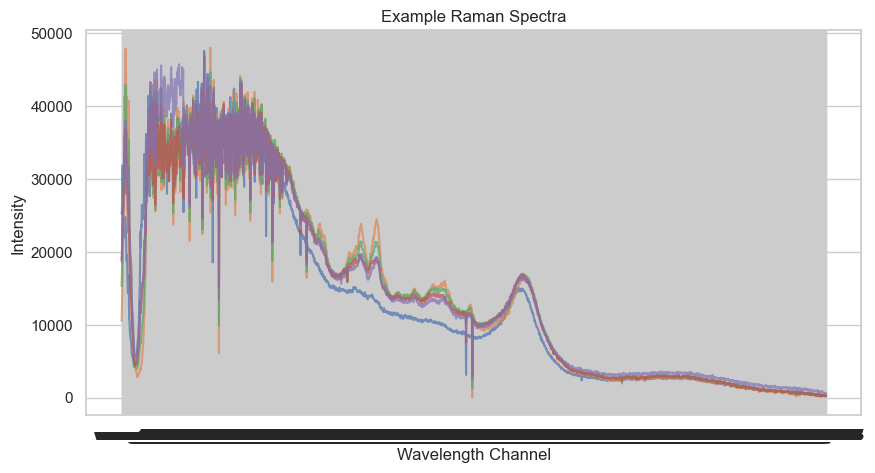

In [16]:
plt.figure(figsize=(10,5))

for i in range(5):
    plt.plot(df[wave_cols].iloc[i], alpha=0.7)

plt.title("Example Raman Spectra")

plt.xlabel("Wavelength Channel")

plt.ylabel("Intensity")

plt.show()



In [17]:

print("\nCalculating Correlation with Glucose")

corr = df[wave_cols].corrwith(df['glucose_mM'])

print("Correlation Calculated")



Calculating Correlation with Glucose
Correlation Calculated


In [18]:

# Top Correlated Features
top_features = corr.abs().nlargest(10)

print("\nTop 10 Correlated Wavelengths")

print(top_features)




Top 10 Correlated Wavelengths
wave_178    0.927266
wave_164    0.926686
wave_170    0.926054
wave_150    0.925941
wave_126    0.925284
wave_151    0.924959
wave_162    0.924440
wave_172    0.923423
wave_109    0.921771
wave_159    0.920665
dtype: float64


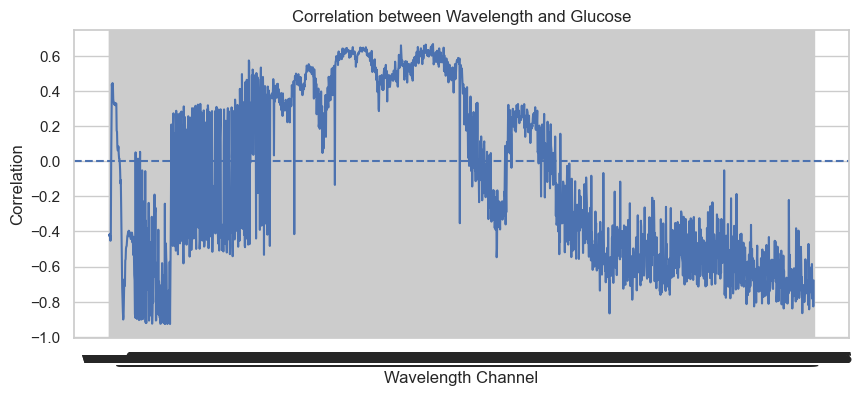

In [19]:

plt.figure(figsize=(10,4))

plt.plot(corr)

plt.axhline(0, linestyle="--")

plt.title("Correlation between Wavelength and Glucose")

plt.xlabel("Wavelength Channel")

plt.ylabel("Correlation")

plt.show()

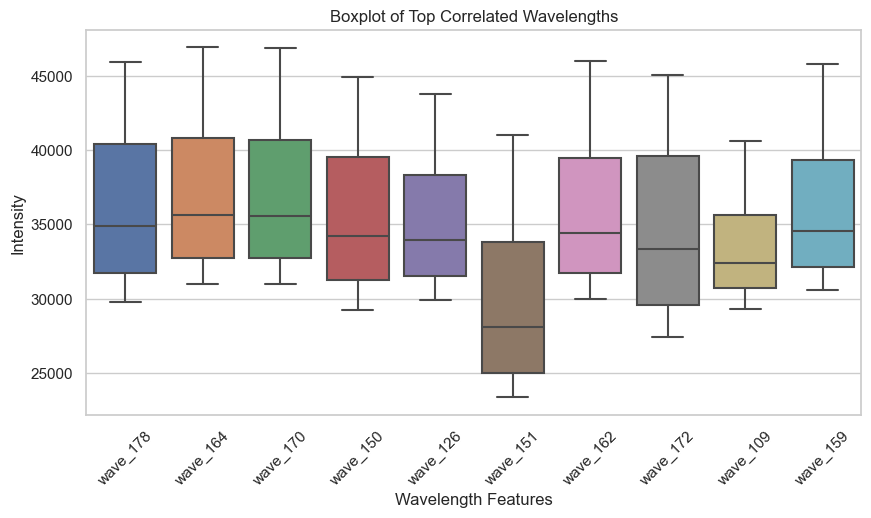

In [20]:

top_wave = top_features.index.tolist()

plt.figure(figsize=(10,5))

sns.boxplot(data=df[top_wave])

plt.title("Boxplot of Top Correlated Wavelengths")

plt.xlabel("Wavelength Features")

plt.ylabel("Intensity")

plt.xticks(rotation=45)

plt.show()



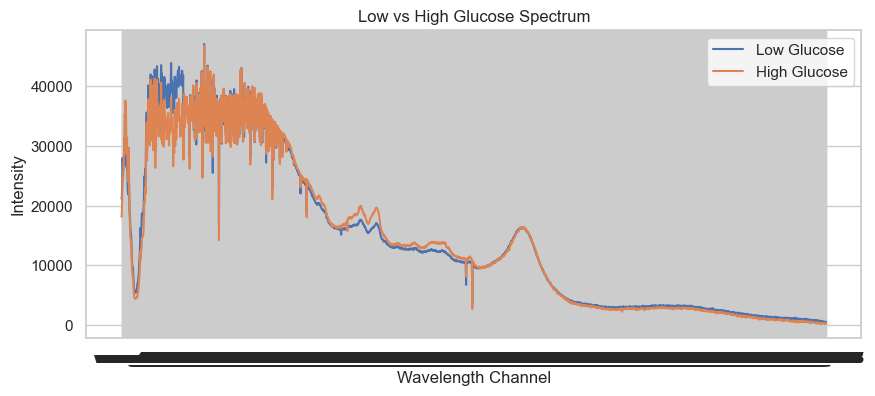

In [21]:
low_spec = df[df['high_glucose']==0][wave_cols].mean()

high_spec = df[df['high_glucose']==1][wave_cols].mean()

plt.figure(figsize=(10,4))

plt.plot(low_spec, label="Low Glucose")

plt.plot(high_spec, label="High Glucose")

plt.title("Low vs High Glucose Spectrum")

plt.xlabel("Wavelength Channel")

plt.ylabel("Intensity")

plt.legend()

plt.show()


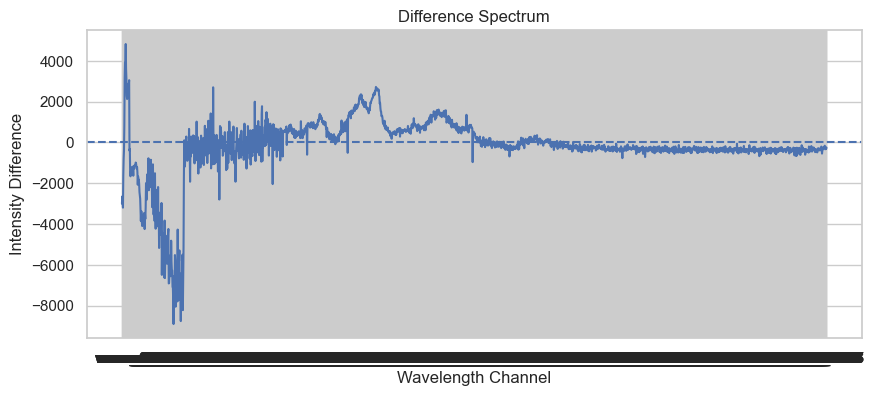

In [22]:
difference = high_spec - low_spec

plt.figure(figsize=(10,4))

plt.plot(difference)

plt.axhline(0, linestyle="--")

plt.title("Difference Spectrum")

plt.xlabel("Wavelength Channel")

plt.ylabel("Intensity Difference")

plt.show()


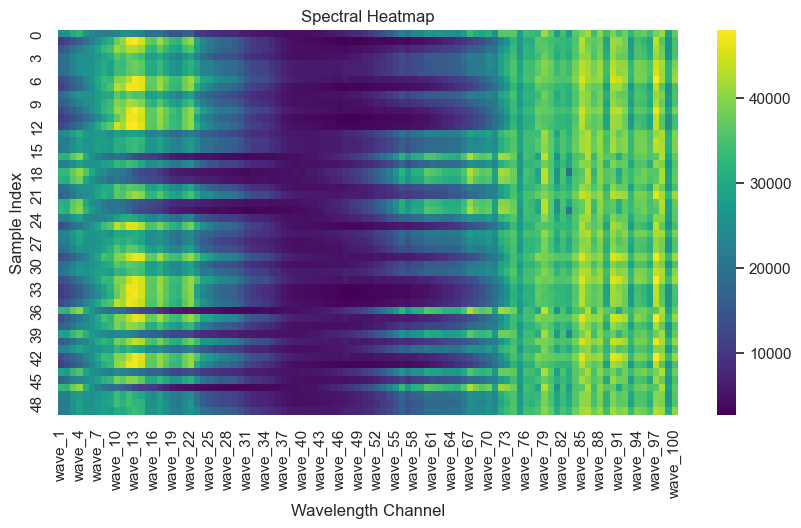

In [23]:
sample_data = df[wave_cols[:100]].iloc[:50]

plt.figure(figsize=(10,5))

sns.heatmap(sample_data, cmap="viridis")

plt.title("Spectral Heatmap")

plt.xlabel("Wavelength Channel")

plt.ylabel("Sample Index")

plt.show()


In [24]:

print("\nSpectral Statistics")

print("Mean Intensity:", df[wave_cols].values.mean())

print("Std Intensity:", df[wave_cols].values.std())

print("Min Intensity:", df[wave_cols].values.min())

print("Max Intensity:", df[wave_cols].values.max())


Spectral Statistics
Mean Intensity: 14201.307853676695
Std Intensity: 12667.266221685437
Min Intensity: 0.0
Max Intensity: 51581.5


In [25]:
print("\n================================")

print("EDA SUMMARY")

print("================================")

print("Total Samples:", len(df))

print("Total Spectral Features:", len(wave_cols))

print("Missing Values:", missing_total)

print("Duplicate Rows:", duplicates)

print("\nGlucose Statistics")

print("Minimum:", df['glucose_mM'].min())

print("Maximum:", df['glucose_mM'].max())

print("Mean:", df['glucose_mM'].mean())

print("Standard Deviation:", df['glucose_mM'].std())

print("\nClass Distribution")

print(df['high_glucose'].value_counts(normalize=True))

print("\nEDA Completed Successfully")

print("================================")


EDA SUMMARY
Total Samples: 10000
Total Spectral Features: 2048
Missing Values: 0
Duplicate Rows: 0

Glucose Statistics
Minimum: 5.0
Maximum: 149.96
Mean: 76.65317399999999
Standard Deviation: 41.70635649973475

Class Distribution
1    0.65
0    0.35
Name: high_glucose, dtype: float64

EDA Completed Successfully


In [26]:
print(df.columns)

Index(['sample_id', 'wave_1', 'wave_2', 'wave_3', 'wave_4', 'wave_5', 'wave_6',
       'wave_7', 'wave_8', 'wave_9',
       ...
       'wave_2041', 'wave_2042', 'wave_2043', 'wave_2044', 'wave_2045',
       'wave_2046', 'wave_2047', 'wave_2048', 'glucose_mM', 'high_glucose'],
      dtype='object', length=2051)


In [27]:
df = df.drop(columns=["sample_id"], errors="ignore")

# Spectral features
wave_cols = [c for c in df.columns if c.startswith("wave_")]

# Feature matrix
X = df[wave_cols]

# Target variable
y = df["high_glucose"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (10000, 2048)
Target Shape: (10000,)


In [28]:
# Import libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

# Spectral features
X = df[wave_cols]

print("Original Shape:", X.shape)

Original Shape: (10000, 2048)


In [29]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data Standardized")

Data Standardized


In [30]:
pca = PCA(n_components=30)

X_pca = pca.fit_transform(X_scaled)

print("PCA Reduced Shape:", X_pca.shape)

PCA Reduced Shape: (10000, 30)


In [31]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance of first 10 components:")
print(explained_variance[:10])

Explained Variance of first 10 components:
[5.71972247e-01 2.84931237e-01 8.83397700e-02 1.26117001e-02
 7.88410299e-03 4.35020364e-03 2.51966363e-03 1.27696713e-03
 8.78678261e-04 4.37869878e-04]


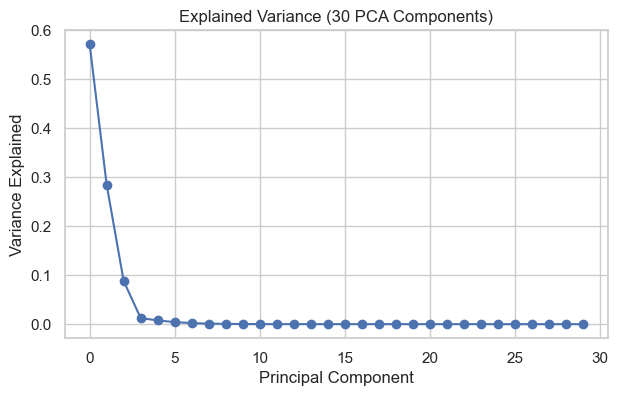

In [32]:
plt.figure(figsize=(7,4))

plt.plot(explained_variance, marker='o')

plt.title("Explained Variance (30 PCA Components)")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")

plt.show()

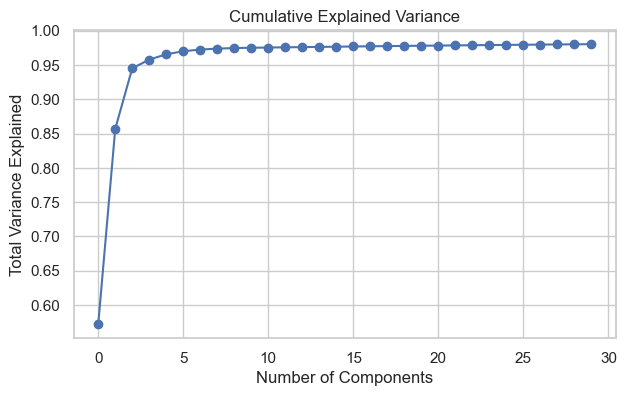

In [33]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(7,4))

plt.plot(cumulative_variance, marker='o')

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Total Variance Explained")

plt.show()

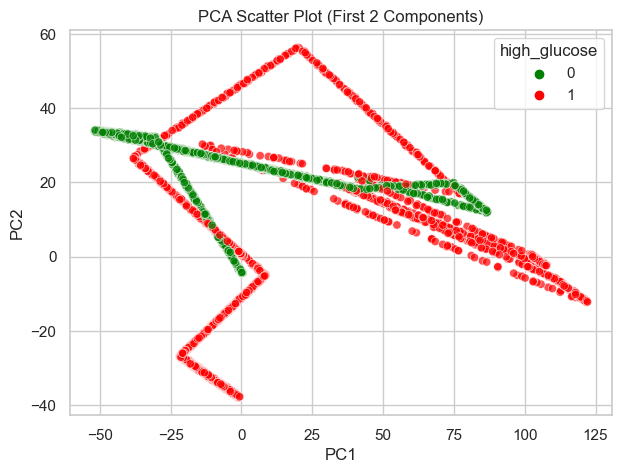

In [34]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['high_glucose'],
    palette=["green","red"],
    alpha=0.7
)

plt.title("PCA Scatter Plot (First 2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [35]:
mds = MDS(n_components=2, random_state=42)

X_mds = mds.fit_transform(X_scaled[:500])

C:\Users\serin\anaconda3\lib\site-packages\sklearn\manifold\_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


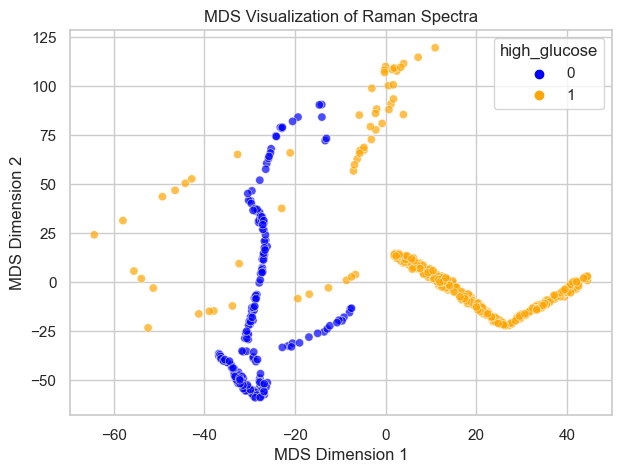

In [36]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X_mds[:,0],
    y=X_mds[:,1],
    hue=df['high_glucose'][:500],
    palette=["blue","orange"],
    alpha=0.7
)

plt.title("MDS Visualization of Raman Spectra")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")

plt.show()

In [37]:
print("===================================")
print("DIMENSIONALITY REDUCTION SUMMARY")
print("===================================")

print("Original Features:", len(wave_cols))
print("Reduced Features (PCA):", X_pca.shape[1])

print("Total Variance Explained:", cumulative_variance[-1])

print("PCA reduced 2048 spectral features to 30 components")
print("===================================")

DIMENSIONALITY REDUCTION SUMMARY
Original Features: 2048
Reduced Features (PCA): 30
Total Variance Explained: 0.980420763619232
PCA reduced 2048 spectral features to 30 components


In [38]:
# MODEL TRAINING PREPARATION
# ======================================

X = df[wave_cols]
y = df["high_glucose"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (10000, 2048)
Target Shape: (10000,)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (8000, 2048)
Testing Data : (2000, 2048)


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Standardized")

Data Standardized


In [41]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Training PCA Shape:", X_train_pca.shape)
print("Testing PCA Shape :", X_test_pca.shape)

Training PCA Shape: (8000, 30)
Testing PCA Shape : (2000, 30)


In [44]:
# ======================================
# NON-LINEARITY HANDLING USING KERNEL PCA
# ======================================

from sklearn.decomposition import KernelPCA

kpca = KernelPCA(
    n_components=30,
    kernel="rbf",
    gamma=0.01
)

X_train_kpca = kpca.fit_transform(X_train_scaled)
X_test_kpca = kpca.transform(X_test_scaled)

print("Training KPCA Shape:", X_train_kpca.shape)
print("Testing KPCA Shape :", X_test_kpca.shape)

Training KPCA Shape: (8000, 30)
Testing KPCA Shape : (2000, 30)


In [46]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_pca, y_train)

y_pred_log = log_model.predict(X_test_pca)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       700
           1       1.00      1.00      1.00      1300

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_pca, y_train)

y_pred_rf = rf_model.predict(X_test_pca)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       700
           1       1.00      1.00      1.00      1300

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [48]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train_pca, y_train)

y_pred_svm = svm_model.predict(X_test_pca)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.989
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       700
           1       0.99      1.00      0.99      1300

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [50]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train_pca, y_train)

y_pred_gb = gb_model.predict(X_test_pca)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

print(classification_report(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.9985
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       700
           1       1.00      1.00      1.00      1300

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [51]:
results = {
    "Model": ["Logistic Regression", "SVM", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ]
}

import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy
0  Logistic Regression    0.9990
1                  SVM    0.9890
2        Random Forest    0.9995
3    Gradient Boosting    0.9985


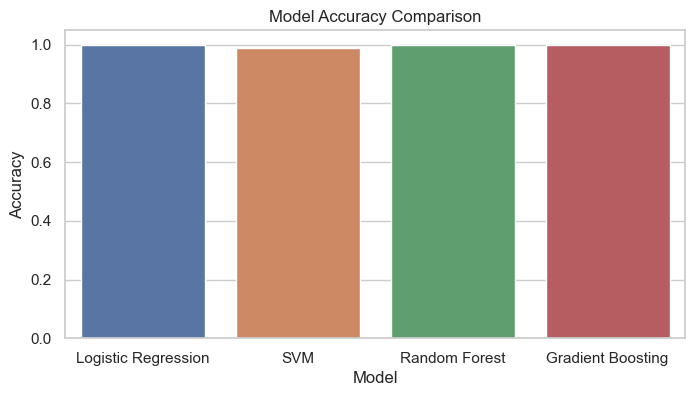

In [52]:
plt.figure(figsize=(8,4))

sns.barplot(data=results_df, x="Model", y="Accuracy")

plt.title("Model Accuracy Comparison")

plt.show()

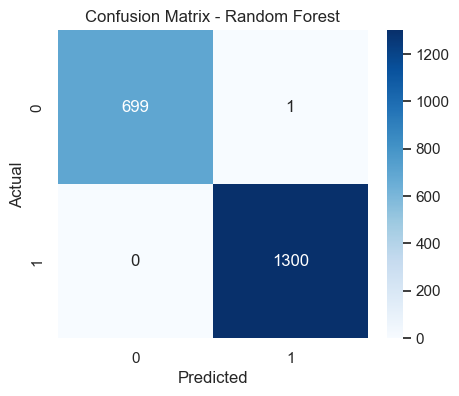

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       700
           1       1.00      1.00      1.00      1300

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [54]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Report
print(classification_report(y_test, y_pred_rf))